In [73]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import ta
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not available')

pd.set_option('display.max_columns', 40)

print('All imports OK.')

All imports OK.


In [74]:
# Download historical stock data
# For prototype NVIDIA (NVDA) is our test case
# yfinance pulls daily OHLCV data directly from Yahoo Finance API.
TICKER = "NVDA"

df = yf.download(TICKER, start="2020-01-01", end="2025-01-01")
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"Downloaded {len(df)} trading days for {TICKER}")
df.head(20)

[*********************100%***********************]  1 of 1 completed

Downloaded 1258 trading days for NVDA


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,5.957138,5.957138,5.877928,5.928335,237536000
2020-01-03,5.861788,5.905490,5.812871,5.837702,205384000
2020-01-06,5.886371,5.891586,5.742602,5.768674,262636000
2020-01-07,5.957635,6.003323,5.869734,5.914678,314856000
2020-01-08,5.968808,6.010027,5.913436,5.953413,277108000
2020-01-09,6.034361,6.106619,5.980727,6.054971,255112000
2020-01-10,6.066641,6.171675,6.052488,6.141382,316296000
2020-01-13,6.256845,6.281924,6.126980,6.149576,319840000
2020-01-14,6.140140,6.239463,6.126979,6.214135,359088000


## Feature engineering


In [75]:
def add_features(df):
    df = df.copy()
    close = df["Close"].squeeze() # daily closing price as a plain 1-D series

    # MA Ratio: is short-term momentum above the long-term trend?
    # MA10/MA50 > 1 = short-term price is rising relative to the trend (bullish)
    df["MA10"] = close.rolling(10).mean()
    df["MA50"] = close.rolling(50).mean()
    df["MA10_50_ratio"] = df["MA10"]/df["MA50"]

    # Daily Return: how much did the price move today?
    df["Daily_Return"] = close.pct_change()

    # 5-Day Return: short-term momentum over the past week
    df["Return_5d"] = close.pct_change(5)

    # Volatility: how much has price fluctuate recently?
    # High = uncertain market; Low = stable trend
    df["Volatility"] = df["Daily_Return"].rolling(10).std()

    # Bollinger Band %: where is today's price sitting within the band range?
    # 0 = at the lower band (possibly oversold), 1 = at the upper band (overbought)
    bb = ta.volatility.BollingerBands(close)
    df["BB_pct"] = (close - bb.bollinger_lband())/(bb.bollinger_hband() - bb.bollinger_lband())

    # RSI: Relative Strength Index - momentum oscillator scaled 0-100
    # RSI > 70 = overbought (price may fall), < 30 = oversold (price may rise)
    df["RSI"] = ta.momentum.rsi(close, window=14)

    return df

In [76]:
# Apply features and create the prediction target
df = add_features(df)

# Target: will the stock price be HIGHER in 20 trading days?
# 1 = Bullish (price rises)  |  0 = Bearish (price falls or stays flat)

HORIZON = 20

df["Target"] = (df["Close"].squeeze().shift(-HORIZON) > df["Close"].squeeze()).astype(int)
df.dropna(inplace=True) # drop rows where future data does not exist yet

print(f"Usable rows: {len(df)}")
print(f"Bullish (1): {df['Target'].mean():.1%}   Bearish (0): {1 - df['Target'].mean():.1%}")
df[["Close", "MA10_50_ratio", "Volatility", "BB_pct", "RSI", "Target"]].tail(40)

Usable rows: 1209
Bullish (1): 65.7%   Bearish (0): 34.3%


Price,Close,MA10_50_ratio,Volatility,BB_pct,RSI,Target
Date,,,,,,
2024-11-04,135.685913,1.107154,0.019780,0.400541,53.725582,1
2024-11-05,139.535583,1.101862,0.022482,0.649796,58.676839,1
2024-11-06,145.220322,1.103631,0.024204,0.988791,64.685753,0
2024-11-07,148.481598,1.106261,0.024867,1.078817,67.596818,0
2024-11-08,147.234940,1.105822,0.025268,0.939236,65.378215,0
2024-11-11,144.871262,1.105049,0.025872,0.777380,61.272007,0
2024-11-12,147.893143,1.103597,0.026445,0.908155,64.354397,0
2024-11-13,145.878555,1.102118,0.026453,0.767217,60.875826,0
2024-11-14,146.367264,1.106174,0.019146,0.766772,61.420612,0


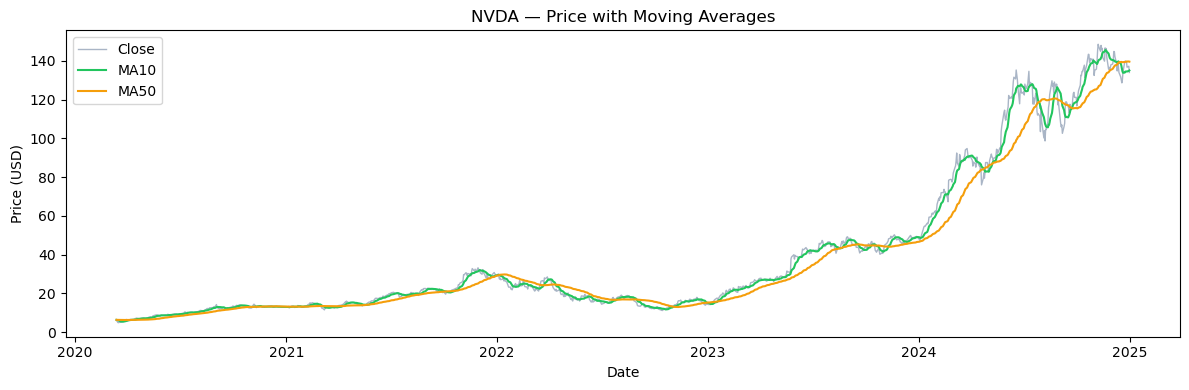

In [77]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Close"], linewidth=1, color="#94a3b8", label="Close", alpha=0.8)
plt.plot(df.index, df["MA10"], linewidth=1.5, color="#22c55e", label="MA10")
plt.plot(df.index, df["MA50"], linewidth=1.5, color="#f59e0b", label="MA50")
plt.title(f"{TICKER} — Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
# Train/Test Split
FEATURES = ["MA10_50_ratio", "Daily_Return", "Return_5d", "Volatility", "BB_pct", "RSI"]

split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

X_train, y_train = df[FEATURES].iloc[:split].values, df["Target"].iloc[:split].values
X_test, y_test  = df[FEATURES].iloc[split:].values,  df["Target"].iloc[split:].values

print(f"Training : {split} rows  ({df.index[0].date()} → {df.index[split-1].date()})")
print(f"Testing  : {len(df)-split} rows  ({df.index[split].date()} → {df.index[-1].date()})")

Training : 967 rows  (2020-03-13 → 2024-01-16)
Testing  : 242 rows  (2024-01-17 → 2024-12-31)


In [79]:
# Scale features and train the model

# Features are on different scales (RSI is 0-100; Daily_Return is ~0.01-0.05)
# StandardScaler centres each feature at 0 with std=1 so the model treats them fairly
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# class_weight='balanced' prevents the model from favouring the majority class
model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
model.fit(X_train_s, y_train)

print("Model trained")

Model trained


Classification Report
              precision    recall  f1-score   support

     Bearish       0.23      0.19      0.21        93
     Bullish       0.54      0.58      0.56       149

    accuracy                           0.43       242
   macro avg       0.38      0.39      0.38       242
weighted avg       0.42      0.43      0.42       242

ROC-AUC : 0.364   (0.5 = random guessing, 1.0 = perfect)
Baseline: 0.616   (accuracy if predicted always Bullish)


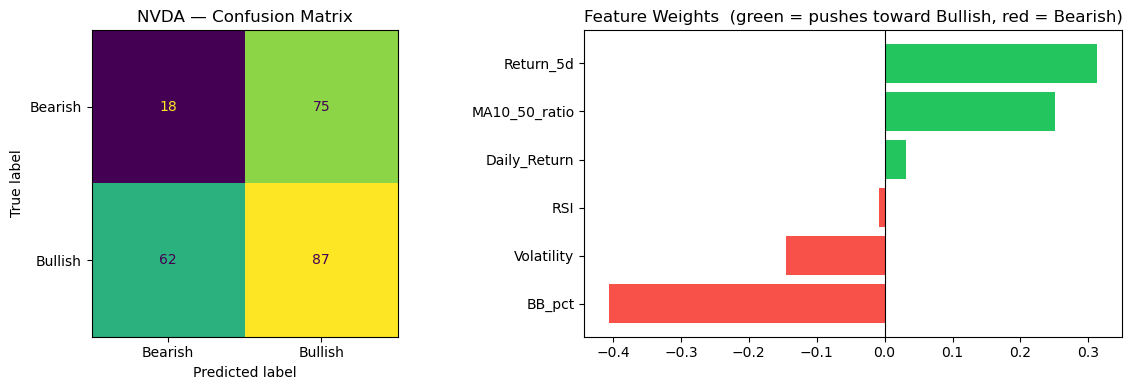

In [80]:
# Evaluate on held-out test data
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1] # probability the signal is Bullish

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=["Bearish", "Bullish"]))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC : {auc:.3f}   (0.5 = random guessing, 1.0 = perfect)")
print(f"Baseline: {y_test.mean():.3f}   (accuracy if predicted always Bullish)")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: confusion matrix shows how often each class was correctly predicted
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Bearish", "Bullish"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"{TICKER} — Confusion Matrix")

# Right: feature weights show which indicators push toward Bullish vs Bearish
coef_df = pd.DataFrame({"Feature": FEATURES, "Weight": model.coef_[0]}).sort_values("Weight")
colors = ["#f85149" if w < 0 else "#22c55e" for w in coef_df["Weight"]]
axes[1].barh(coef_df["Feature"], coef_df["Weight"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Weights  (green = pushes toward Bullish, red = Bearish)")

plt.tight_layout()
plt.show()

In [81]:
# Live prediction
live = yf.download(TICKER, period="3mo", auto_adjust=True, progress=False)
if isinstance(live.columns, pd.MultiIndex):
    live.columns = live.columns.get_level_values(0)

live = add_features(live)
live.dropna(inplace=True)

# Take the most recent row, scale it the same way as training, and predict
latest_row = live[FEATURES].iloc[[-1]]
pred = model.predict(scaler.transform(latest_row))[0]
confidence = model.predict_proba(scaler.transform(latest_row))[0].max()
price = float(live["Close"].iloc[-1])
date = live.index[-1].date()

signal = "BULLISH" if pred == 1 else "BEARISH"

print(f"\n{'━'*40}")
print(f" {TICKER} Prediction  —  {date}")
print(f"{'━'*40}")
print(f" Current price : ${price:.2f}")
print(f" Signal        : {signal}")
print(f" Confidence    : {confidence:.1%}")
print(f" Horizon       : {HORIZON} trading days")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 NVDA Prediction  —  2026-09-18
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Current price : $222.27
 Signal        : BULLISH
 Confidence    : 51.7%
 Horizon       : 20 trading days


C:\Users\limja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\limja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


---
## Comparing multiple stocks and multiple models

The prototype above trains one model, Logistic Regression, on one stock, NVDA.
Testing on a single high-volatility technology stock is not enough to draw
general conclusions, so this section repeats the same approach across four
stocks from different sectors and volatility levels, and compares three models
instead of one.

Everything below reuses the `add_features()` function, the `HORIZON` value, and
the `FEATURES` list defined above, so that both sections compute their features
in exactly the same way.


In [82]:
# Four stocks covering different sectors and volatility levels
TICKERS = ["NVDA", "JNJ", "XOM", "KO"]
# NVDA = Technology, high volatility
# JNJ  = Healthcare, low volatility
# XOM  = Energy, cyclical
# KO   = Consumer staples, low volatility

### Downloading and preparing data for every stock

The steps used for NVDA above are wrapped into a single function. It downloads
price history, adds the features, creates the target column, and drops rows
where the rolling windows or the future price are not yet available. This lets
the same process run for each ticker in turn.


In [83]:
def download_and_engineer(ticker):
    # Download price history for one ticker and build its feature + target table.
    data = yf.download(ticker, start="2020-01-01", end="2025-01-01", progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = add_features(data)  # same function defined earlier in this notebook
    data["Target"] = (data["Close"].squeeze().shift(-HORIZON) > data["Close"].squeeze()).astype(int)
    data.dropna(inplace=True)  # drop rows where indicators or future price are not available yet
    return data

# Download and engineer features for all four stocks
stock_data = {ticker: download_and_engineer(ticker) for ticker in TICKERS}

# Quick check - how much usable data does each stock have and is it balanced?
for ticker, data in stock_data.items():
    print(f"{ticker}: {len(data)} usable rows, {data['Target'].mean():.1%} Bullish")

NVDA: 1209 usable rows, 65.7% Bullish
JNJ: 1209 usable rows, 50.0% Bullish
XOM: 1209 usable rows, 58.8% Bullish
KO: 1209 usable rows, 59.6% Bullish


### Defining the three models

Three models are compared. Logistic Regression is simple and interpretable and
is the same model used in the NVDA prototype. Random Forest can capture
non-linear patterns while remaining reasonably easy to reason about. XGBoost is
usually the strongest performer of the three but is the hardest to interpret.

Setting `class_weight="balanced"`, and `scale_pos_weight` for XGBoost stops a
model from simply predicting the majority class throughout. This is the same
adjustment applied in the prototype.


In [84]:
def make_models(y_train):
    # Return a fresh, untrained copy of each model.
    # Tells XGBoost how much more to weigh the rarer class
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models = {
        "LogisticRegression": lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ),
        "RandomForest": lambda: RandomForestClassifier(
            random_state=42, n_estimators=300, class_weight="balanced"
        ),
    }
    if XGBOOST_AVAILABLE:
        models["XGBoost"] = lambda: xgb.XGBClassifier(
            random_state=42, eval_metric="logloss", scale_pos_weight=pos_weight
        )
    return models

### Cross-validation helper

`TimeSeriesSplit` validates a model across several different time windows rather
than on one test period alone. This checks that a result is consistent and not
an artefact of where the single split happened to fall.


In [85]:
def cross_validated_roc_auc(model_fn, X_train, y_train, n_splits=5):
    # Train and validate across 5 rolling time windows, return the average ROC-AUC
    splitter = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    for train_idx, val_idx in splitter.split(X_train):
        model = model_fn()
        model.fit(X_train[train_idx], y_train.iloc[train_idx])
        val_proba = model.predict_proba(X_train[val_idx])[:, 1]
        scores.append(roc_auc_score(y_train.iloc[val_idx], val_proba))

    return sum(scores) / len(scores)

### Running the comparison

For each stock the data is split chronologically at 80/20, as in the NVDA
prototype. Each model is cross-validated on the training portion and then
evaluated on the untouched test set. The naive baseline of always predicting
Bullish is recorded for every stock, so that each model can be checked against
it rather than judged on accuracy alone.


In [86]:
results = []

for ticker, data in stock_data.items():
    # Same chronological split as the NVDA prototype
    split = int(len(data) * 0.8)
    X_train = data[FEATURES].iloc[:split].values
    y_train = data["Target"].iloc[:split]
    X_test  = data[FEATURES].iloc[split:].values
    y_test  = data["Target"].iloc[split:]

    # Fit the scaler on training data only, then apply it to the test data
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    naive_baseline = y_test.mean()  # accuracy if we always predicted Bullish

    for model_name, model_fn in make_models(y_train).items():
        cv_score = cross_validated_roc_auc(model_fn, X_train_s, y_train)

        # Train once more on the full training set, then check the held-out test set
        model = model_fn()
        model.fit(X_train_s, y_train)
        test_proba = model.predict_proba(X_test_s)[:, 1]
        test_pred  = (test_proba >= 0.5).astype(int)

        results.append({
            "Ticker": ticker,
            "Model": model_name,
            "CV ROC-AUC": round(cv_score, 3),
            "Test ROC-AUC": round(roc_auc_score(y_test, test_proba), 3),
            "Accuracy": round(accuracy_score(y_test, test_pred), 3),
            "Naive Baseline": round(naive_baseline, 3),
        })

# One row per stock/model combination
results_df = pd.DataFrame(results)
results_df

,Ticker,Model,CV ROC-AUC,Test ROC-AUC,Accuracy,Naive Baseline
0,NVDA,LogisticRegression,0.496,0.364,0.434,0.616
1,NVDA,RandomForest,0.520,0.435,0.554,0.616
2,NVDA,XGBoost,0.482,0.460,0.517,0.616
3,JNJ,LogisticRegression,0.582,0.347,0.380,0.393
4,JNJ,RandomForest,0.549,0.467,0.442,0.393
5,JNJ,XGBoost,0.559,0.470,0.467,0.393
6,XOM,LogisticRegression,0.537,0.497,0.450,0.545
7,XOM,RandomForest,0.496,0.536,0.508,0.545
8,XOM,XGBoost,0.490,0.507,0.500,0.545
9,KO,LogisticRegression,0.581,0.378,0.393,0.541


### Which model performs best overall

Averaging each model's test ROC-AUC across all four stocks gives a ranking based
on evidence from several stocks rather than from NVDA alone. This addresses the
third project question, which asked which model is most suitable.


In [87]:
model_ranking = results_df.groupby("Model")["Test ROC-AUC"].mean().sort_values(ascending=False)
print("Average Test ROC-AUC by model, across all four stocks:")
model_ranking

Average Test ROC-AUC by model, across all four stocks:


Model
XGBoost               0.45150
RandomForest          0.45075
LogisticRegression    0.39650
Name: Test ROC-AUC, dtype: float64

### Retraining the best model for deployment

The comparison above uses a separate train and test split for each stock, which
is the fair way to evaluate the models against each other. The model that is
actually deployed in the dashboard is different. It is the winning model type
retrained on all four stocks combined, so that it has seen a wider range of
market conditions than any single stock could provide.


In [88]:
best_model_name = model_ranking.index[0]
print(f"Best performing model: {best_model_name}")

# Combine every stock's rows into one larger training set
pooled_data = pd.concat(stock_data.values(), ignore_index=True)
X_pooled = pooled_data[FEATURES].values
y_pooled = pooled_data["Target"]

final_scaler = StandardScaler()
X_pooled_s = final_scaler.fit_transform(X_pooled)

final_model = make_models(y_pooled)[best_model_name]()
final_model.fit(X_pooled_s, y_pooled)

# Save so the Streamlit dashboard can load the trained model directly
joblib.dump(final_model, "model.pkl")
joblib.dump(final_scaler, "scaler.pkl")
print("Saved model.pkl and scaler.pkl")

Best performing model: XGBoost
Saved model.pkl and scaler.pkl


---
## Backtesting

ROC-AUC and accuracy show whether the model labels days correctly. They do not
show whether acting on those labels would have been profitable. This section
uses Backtrader to simulate trading on the model's signals and compares the
outcome against a buy-and-hold benchmark, which answers the same question about
beating a naive baseline in financial terms rather than classification terms.

The model used in each backtest is retrained on that stock's training portion
only, using the same 80/20 split as above, and generates signals exclusively for
the test portion. Training a model on the period it is then backtested on would
make the result meaningless, since it would be recalling the past rather than
predicting it.

The trading rule is kept deliberately simple, following the contingency plan in
Section 3.7 of the report. The strategy moves fully into the stock when the
signal is Bullish and fully into cash when it is Bearish. There is no position
sizing, no stop-loss, and no short selling.


In [89]:
import backtrader as bt

class SignalData(bt.feeds.PandasData):
    """Extends Backtrader's standard OHLCV feed with one extra column: our
    model's daily signal (1 = Bullish, 0 = Bearish)."""
    lines = ("signal",)
    params = (("signal", -1),)


class SignalStrategy(bt.Strategy):
    """Simplest possible long/flat rule: fully invested when the model says
    Bullish, fully in cash when it says Bearish."""
    def next(self):
        signal = self.data.signal[0]
        if signal == 1 and not self.position:
            self.order_target_percent(target=1.0)   # go all-in long
        elif signal == 0 and self.position:
            self.order_target_percent(target=0.0)   # exit to cash


class BuyAndHold(bt.Strategy):
    """Benchmark: buy once at the start of the test period, hold throughout."""
    def next(self):
        if not self.position:
            self.order_target_percent(target=1.0)


class ValueTracker(bt.Analyzer):
    """Records the portfolio's value every day, so the equity curve can be
    plotted afterwards."""
    def start(self):
        self.values = []
    def next(self):
        self.values.append(self.strategy.broker.getvalue())

### The backtest runner

`run_backtest()` wraps the usual Backtrader setup into one reusable function.
This covers the Cerebro engine, the starting cash, a commission of 0.1% per
trade, and three analysers that record return, Sharpe ratio, and drawdown. The
function is called once per strategy for each stock.


In [90]:
def run_backtest(strategy_cls, feed_df, starting_cash=10000):
    cerebro = bt.Cerebro()
    cerebro.broker.setcash(starting_cash)
    cerebro.broker.setcommission(commission=0.001)  # 0.1% per trade - realistic assumption

    cerebro.adddata(SignalData(dataname=feed_df))
    cerebro.addstrategy(strategy_cls)
    cerebro.addanalyzer(bt.analyzers.Returns, _name="returns")
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name="sharpe", timeframe=bt.TimeFrame.Days)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
    cerebro.addanalyzer(ValueTracker, _name="tracker")

    result = cerebro.run()
    strat = result[0]

    return {
        "final_value": cerebro.broker.getvalue(),
        "total_return_pct": strat.analyzers.returns.get_analysis().get("rtot", 0) * 100,
        "sharpe": strat.analyzers.sharpe.get_analysis().get("sharperatio"),
        "max_drawdown_pct": strat.analyzers.drawdown.get_analysis().max.drawdown,
        "value_series": strat.analyzers.tracker.values,
    }

### Running the backtest for every stock

For each stock the winning model type is retrained on the training split, one
signal is generated for every day in the test period, and both the signal
strategy and the buy-and-hold benchmark are run across that same period.


In [91]:
backtest_results = []
equity_curves = {}

for ticker, data in stock_data.items():
    # Retrain fresh here so the model being backtested has never seen the test period during training
    split = int(len(data) * 0.8)
    train, test = data.iloc[:split].copy(), data.iloc[split:].copy()

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(train[FEATURES])
    X_test_s = scaler.transform(test[FEATURES])

    model = make_models(train["Target"])[best_model_name]()
    model.fit(X_train_s, train["Target"])

    # One signal per day across the whole test period, not just the most recent day
    test["Signal"] = model.predict(X_test_s)
    feed_df = test[["Open", "High", "Low", "Close", "Volume", "Signal"]].rename(columns={"Signal": "signal"})

    strategy_result = run_backtest(SignalStrategy, feed_df)
    buyhold_result = run_backtest(BuyAndHold, feed_df)

    backtest_results.append({
        "Ticker": ticker,
        "Strategy Return %": round(strategy_result["total_return_pct"], 2),
        "Buy & Hold Return %": round(buyhold_result["total_return_pct"], 2),
        "Strategy Sharpe": round(strategy_result["sharpe"], 3) if strategy_result["sharpe"] else None,
        "Buy & Hold Sharpe": round(buyhold_result["sharpe"], 3) if buyhold_result["sharpe"] else None,
        "Strategy Max Drawdown %": round(strategy_result["max_drawdown_pct"], 2),
        "Buy & Hold Max Drawdown %": round(buyhold_result["max_drawdown_pct"], 2),
    })
    equity_curves[ticker] = {
        "dates": feed_df.index[-len(strategy_result["value_series"]):],
        "strategy": strategy_result["value_series"],
        "buyhold": buyhold_result["value_series"],
    }

backtest_df = pd.DataFrame(backtest_results)
backtest_df

,Ticker,Strategy Return %,Buy & Hold Return %,Strategy Sharpe,Buy & Hold Sharpe,Strategy Max Drawdown %,Buy & Hold Max Drawdown %
0,NVDA,38.99,78.12,0.074,0.113,20.11,26.87
1,JNJ,8.12,-7.04,0.043,-0.030,7.84,13.59
2,XOM,16.26,13.53,0.075,0.049,9.63,15.09
3,KO,-4.16,7.09,-0.038,0.035,12.70,14.79


### Plotting the equity curves

Portfolio value over time is plotted for both strategies on each stock, which
shows where the two diverge rather than only reporting the final figures.


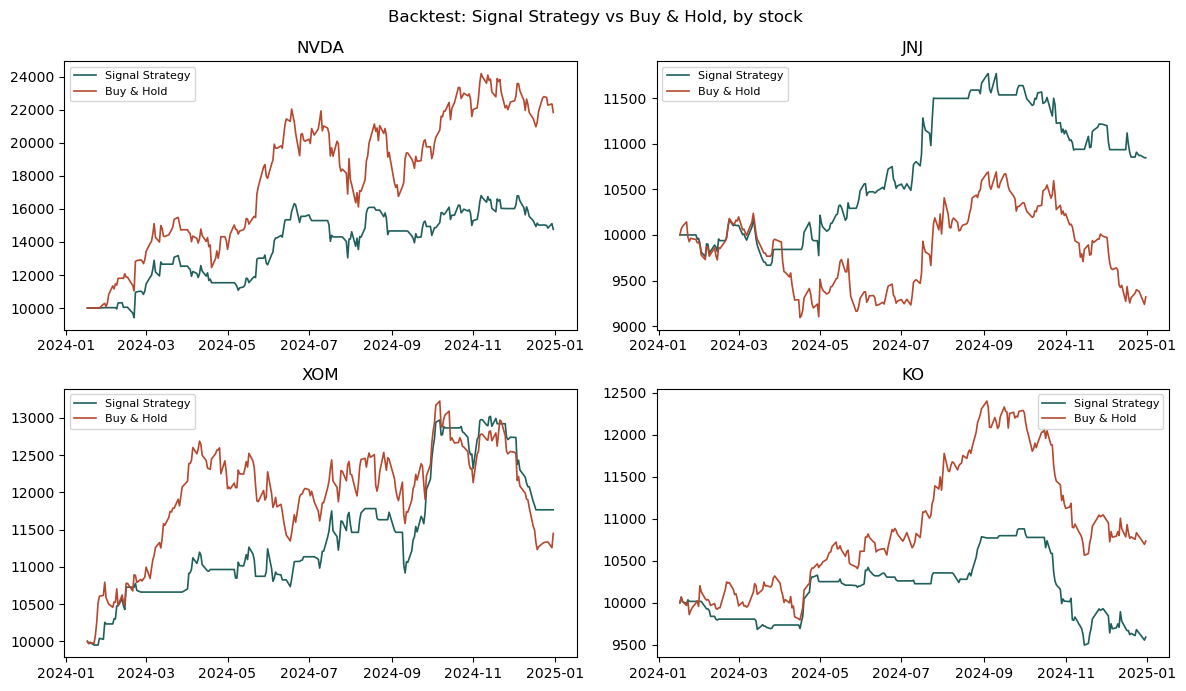

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, ticker in zip(axes.flat, TICKERS):
    curve = equity_curves[ticker]
    ax.plot(curve["dates"], curve["strategy"], label="Signal Strategy", color="#1f5f5b", linewidth=1.2)
    ax.plot(curve["dates"], curve["buyhold"], label="Buy & Hold", color="#b5482e", linewidth=1.2)
    ax.set_title(ticker)
    ax.legend(fontsize=8)

fig.suptitle("Backtest: Signal Strategy vs Buy & Hold, by stock")
plt.tight_layout()
plt.show()

### Summary

`backtest_df` reports, stock by stock, whether the signal would have beaten
buy-and-hold in practice. It complements the classification metrics produced
earlier by measuring a different thing, namely financial outcome rather than
label accuracy.


---
## Scaling up to a larger stock universe

There are two separate reasons for wanting more stocks, and they need different
treatment.

The first is a broader dataset for the deployed model, the one saved as
`model.pkl` for the dashboard. More stocks means the model has been exposed to a
wider range of market conditions. This requires only one larger model fit at the
end, so scaling it to hundreds of stocks is inexpensive.

The second is a broader evaluation sample. Re-running the full three-model
comparison on hundreds of stocks would take a long time, and a results table
with several hundred rows would not be presentable in a report.

The deployment model is therefore retrained on a large pool at S&P 500 scale,
while the evaluation is extended using only the winning model and reported as
aggregate statistics.


In [93]:
import time
import requests

def get_sp500_tickers():
    # Scrape the current S&P 500 constituent list
    try:
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
        response = requests.get(
            "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
            headers=headers, timeout=10,
        )
        response.raise_for_status()
        table = pd.read_html(response.text)[0]
        return table["Symbol"].str.replace(".", "-", regex=False).tolist()
    except Exception as e:
        print(f"Could not fetch S&P 500 list ({type(e).__name__}), using fallback list")
        return [
            "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "V",
            "XOM", "KO", "PG", "UNH", "HD", "DIS", "MA", "BAC", "PFE", "CSCO",
        ]

SP500_TICKERS = get_sp500_tickers()
print(f"Universe size: {len(SP500_TICKERS)} tickers")

MAX_STOCKS = 500
tickers_to_use = SP500_TICKERS[:MAX_STOCKS]

Universe size: 503 tickers


C:\Users\limja\AppData\Local\Temp\ipykernel_16000\222595355.py:13: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)[0]


### Downloading data at scale

At this number of tickers some downloads fail or return too little history to be
usable, because of delistings, recent listings, and gaps in the data.
`download_and_engineer_safe()` returns `None` in those cases rather than raising
an exception, so that one bad ticker does not halt the whole batch. A short pause
between requests avoids overloading the Yahoo Finance API.


In [94]:
def download_and_engineer_safe(ticker):
    # Returns None on failure - lets the batch continue past bad tickers.
    try:
        data = yf.download(ticker, start="2020-01-01", end="2025-01-01", progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        if data.empty or len(data) < 300:  # not enough history for reliable indicators
            return None

        data = add_features(data)
        data["Target"] = (data["Close"].squeeze().shift(-HORIZON) > data["Close"].squeeze()).astype(int)
        data.dropna(inplace=True)
        return data if not data.empty else None
    except Exception:
        return None


large_stock_data = {}
failed_tickers = []

for i, ticker in enumerate(tickers_to_use, 1):
    result = download_and_engineer_safe(ticker)
    if result is not None:
        large_stock_data[ticker] = result
    else:
        failed_tickers.append(ticker)

    if i % 25 == 0:
        print(f"  {i}/{len(tickers_to_use)} processed - {len(large_stock_data)} succeeded so far")
    time.sleep(0.2)  # small pause between requests

print(f"\nDone: {len(large_stock_data)} usable, {len(failed_tickers)} failed/skipped")
if failed_tickers:
    print("Failed tickers:", failed_tickers)

  25/500 processed - 25 succeeded so far
  50/500 processed - 50 succeeded so far
  75/500 processed - 75 succeeded so far
  100/500 processed - 100 succeeded so far
  125/500 processed - 125 succeeded so far
  150/500 processed - 150 succeeded so far
  175/500 processed - 175 succeeded so far


$FDXF: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")

1 Failed download:
['FDXF']: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")


  200/500 processed - 199 succeeded so far
  225/500 processed - 223 succeeded so far


$HONA: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")

1 Failed download:
['HONA']: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")


  250/500 processed - 247 succeeded so far
  275/500 processed - 272 succeeded so far
  300/500 processed - 297 succeeded so far
  325/500 processed - 322 succeeded so far
  350/500 processed - 347 succeeded so far
  375/500 processed - 372 succeeded so far


$Q: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")

1 Failed download:
['Q']: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")


  400/500 processed - 395 succeeded so far


$SNDK: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")

1 Failed download:
['SNDK']: possibly delisted; no price data found  (1d 2020-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1735707600")


  425/500 processed - 418 succeeded so far
  450/500 processed - 443 succeeded so far
  475/500 processed - 468 succeeded so far
  500/500 processed - 493 succeeded so far

Done: 493 usable, 7 failed/skipped
Failed tickers: ['FDXF', 'GEV', 'HONA', 'Q', 'RDDT', 'SNDK', 'SOLV']


### Retraining the deployment model on the large pool

This follows the same approach used for the four-stock pool above, with many
more stocks combined. It overwrites `model.pkl` and `scaler.pkl` with a version
trained on a much broader slice of the market.


In [95]:
large_pooled = pd.concat(large_stock_data.values(), ignore_index=True)
print(f"Pooled dataset: {len(large_pooled)} rows from {len(large_stock_data)} stocks")

X_large = large_pooled[FEATURES].values
y_large = large_pooled["Target"]

large_scaler = StandardScaler()
X_large_s = large_scaler.fit_transform(X_large)

large_model = make_models(y_large)[best_model_name]()
large_model.fit(X_large_s, y_large)

joblib.dump(large_model, "model.pkl")
joblib.dump(large_scaler, "scaler.pkl")
print(f"Retrained {best_model_name} on {len(large_stock_data)} stocks and saved model.pkl / scaler.pkl")

Pooled dataset: 590902 rows from 493 stocks
Retrained XGBoost on 493 stocks and saved model.pkl / scaler.pkl


### Extended evaluation across the full universe

Running the full three-model comparison at this scale is not worth the
computational time, so only the winning model is evaluated across every stock.
The results are reported as aggregate statistics, which gives a far stronger
evidence base than four stocks while remaining presentable in a report.


In [96]:
eval_rows = []

for ticker, data in large_stock_data.items():
    split = int(len(data) * 0.8)
    train, test = data.iloc[:split], data.iloc[split:]
    if len(test) < 20:
        continue  # too little test data for this stock to be meaningful

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(train[FEATURES])
    X_test_s = scaler.transform(test[FEATURES])

    model = make_models(train["Target"])[best_model_name]()
    model.fit(X_train_s, train["Target"])
    proba = model.predict_proba(X_test_s)[:, 1]
    preds = (proba >= 0.5).astype(int)

    eval_rows.append({
        "Ticker": ticker,
        "Test ROC-AUC": roc_auc_score(test["Target"], proba),
        "Accuracy": accuracy_score(test["Target"], preds),
        "Naive Baseline": test["Target"].mean(),
    })

large_eval_df = pd.DataFrame(eval_rows)

above_random = (large_eval_df["Test ROC-AUC"] > 0.5).sum()
beat_baseline = (large_eval_df["Accuracy"] > large_eval_df["Naive Baseline"]).sum()
n = len(large_eval_df)

print(f"Evaluated {n} stocks with {best_model_name}")
print(f"Mean Test ROC-AUC: {large_eval_df['Test ROC-AUC'].mean():.3f}")
print(f"Stocks with ROC-AUC > 0.5 (better than random): {above_random}/{n} ({above_random/n:.1%})")
print(f"Stocks beating their own naive baseline accuracy: {beat_baseline}/{n} ({beat_baseline/n:.1%})")

Evaluated 493 stocks with XGBoost
Mean Test ROC-AUC: 0.504
Stocks with ROC-AUC > 0.5 (better than random): 265/493 (53.8%)
Stocks beating their own naive baseline accuracy: 171/493 (34.7%)


### Summary

Three figures summarise this evaluation. These are the mean ROC-AUC across all
stocks, the proportion of stocks on which the model performed better than
random, and the proportion on which it beat its own naive baseline.

`MAX_STOCKS` controls how far the process scales.
